# **Rice Leaf Disease Detection CNN**

# **Project Introduction:**
  Rice is one of the major cultivated crops in India. Rice crops are susceptible to various diseases at various stages of cultivation. Early detection and remedy are required to maintain the best quality and quantity in rice. Farmers with their limited knowledge, have a difficult time identifying these diseases manually. Therefore, automated image recognition systems using Convolutional Neural Network (CNN) can be very beneficial in such problems.

Domain: Agriculture + deep learning + Computer vision

 *Diseases:*
Leaf Blast,
Bacterial Blight,
Brown Spot.

Objective:
To build a Convolutional Neural Network (CNN) model that classifies rice leaf images into these three disease categories.


# Problem Classification
 Our goal is to build a model that would automatically classify rice leaf diseases. For this, we have taken three major attacking diseases in rice plants like leaf blast, bacterial blight and brown spot. We created a model that would determine if the future data inputs will fall in either of these 3 diseases- leaf,blast, bacterial blight and brown spot.

We have deviced the project into multiple steps

• Loading Data

• Preparing Dataset

• Data Preproocessing

• Model Building

• Trining

Basic check
✔ Data analysis
✔ Image visualization
✔ Image size check
✔ CNN model
✔ Evaluation
✔ confusion matrix



# Import Basic Libraries

In [1]:
 import numpy as np
 import cv2   #converts image into arrays
 import os
 import random
 import matplotlib.pyplot as plt
 import pickle
 import warnings
 warnings.filterwarnings('ignore')
 import tensorflow as tf

# Import Keras Packages

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from glob import glob
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix



# Load The Data

**Drive** mount

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'mycolabnote', '4_Understanding_Convolution_(1).ipynb', 'bigdatafoundation', 'intenship_rice']


define path

In [5]:
data_dir = "/content/drive/MyDrive/intenship_rice"

In [6]:
import os
print(os.listdir(data_dir))


['Bacterial leaf blight-20200814T055237Z-001.zip', 'Leaf smut-20200814T055530Z-001.zip', 'Brown spot-20200814T055208Z-001.zip', 'Bacterial leaf blight', 'Brown spot', 'Leaf smut']


# Check Image Count

In [7]:
import os

data_dir = "/content/drive/MyDrive/intenship_rice"

for cls in ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']:
    print(cls, ":", len(os.listdir(os.path.join(data_dir, cls))))



Bacterial leaf blight : 40
Brown spot : 40
Leaf smut : 39


observation: The dataset is fairly balanced across all three disease classes, which reduces the risk of model bias during training.

In [8]:

import cv2

data_dir = "/content/drive/MyDrive/intenship_rice"

categories = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

for category in categories:
    folder = os.path.join(data_dir, category)
    print("Checking folder:", folder)

    first_image = os.listdir(folder)[0]   # first image automatically
    img_path = os.path.join(folder, first_image)

    print("Image path:", img_path)

    img = cv2.imread(img_path)

    if img is None:
        print(" Image not loaded")
    else:
        print(" Image loaded successfully")
        print("Image shape:", img.shape)

    break   # sirf first category check karega

Checking folder: /content/drive/MyDrive/intenship_rice/Bacterial leaf blight
Image path: /content/drive/MyDrive/intenship_rice/Bacterial leaf blight/DSC_0377.JPG
 Image loaded successfully
Image shape: (897, 3081, 3)


The original images had varying resolutions (e.g., 897x3081). Therefore, all images were resized to 128x128 pixels to ensure consistent input dimensions for the CNN model.

check all image size are same

In [9]:
for category in categories:
    folder = os.path.join(data_dir, category)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    img = cv2.imread(img_path)
    print(category, ":", img.shape)

Bacterial leaf blight : (897, 3081, 3)
Brown spot : (897, 3081, 3)
Leaf smut : (897, 3081, 3)


897 height#the wrod

3081 width

3 color channels (RGB)

Check Colour Channel

In [10]:
print("Channels:", img.shape[2])

Channels: 3


The Output is 3 this is RGB Image

## Data Analysis
visualise sample image

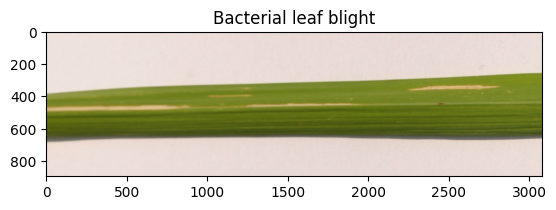

In [11]:
for category in categories:
    folder = os.path.join(data_dir, category)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(category)
    plt.show()
    break

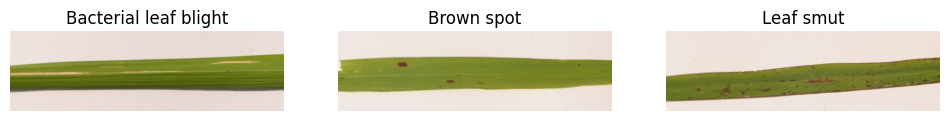

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import os

plt.figure(figsize=(12,4))

# Filter out non-directory items (like zip files) from the data_dir listing
classes = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]

for i, cls in enumerate(classes[:3]): # Iterate only through the first 3 actual class directories
    img_path = os.path.join(data_dir, cls,
      os.listdir(os.path.join(data_dir, cls))[0])
    img = Image.open(img_path)

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

# Load Data into Array

In [13]:
data = []
IMG_SIZE = 128 # Define a constant for the image size

for category in categories:
    folder = os.path.join(data_dir, category)
    label = categories.index(category)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            # Corrected cv2.resize call: img, (width, height)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append([img, label])

In [ ]:
data

[[array([[[221, 227, 238],
          [219, 225, 236],
          [221, 225, 236],
          ...,
          [217, 223, 236],
          [219, 225, 238],
          [218, 222, 233]],
  
         [[221, 227, 238],
          [219, 225, 236],
          [219, 225, 236],
          ...,
          [214, 217, 230],
          [220, 223, 237],
          [219, 225, 236]],
  
         [[220, 226, 237],
          [220, 226, 237],
          [221, 227, 238],
          ...,
          [221, 224, 238],
          [218, 222, 233],
          [219, 222, 233]],
  
         ...,
  
         [[216, 224, 237],
          [219, 225, 238],
          [219, 225, 236],
          ...,
          [217, 222, 237],
          [219, 223, 234],
          [218, 221, 235]],
  
         [[218, 224, 237],
          [216, 223, 238],
          [218, 224, 236],
          ...,
          [215, 221, 234],
          [218, 222, 233],
          [217, 223, 234]],
  
         [[219, 225, 236],
          [219, 225, 238],
          [218, 224, 235

The images were loaded using OpenCV, converted from BGR to RGB format, resized to a fixed dimension, assigned numeric labels, and stored as NumPy arrays for model training.

# Shuffle Data

In [14]:
random.shuffle(data)

Data ka order random bana diya taaki model fair training kare.
dataset was stored class-wise, shuffling was applied to randomize the order of images. This prevents biased learning and ensures balanced batch training.

## Separate Features and Labels

In [15]:
X = []
y = []

for features, label in data:
    X.append(features)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (119, 128, 128, 3)
y shape: (119,)


 The given step image features and corresponding labels were separated and converted into NumPy arrays to prepare the dataset for model training.



# Normalize Data

In [16]:
X = X / 255.0

The pixel values ranged from 0 to 255. To stabilise and speed up model training, normalisation was applied by dividing by 255, converting pixel values to the 0-1 range.

## Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 95
Testing samples: 24


In [ ]:
X_train.shape

(95, 128, 128, 3)

In [ ]:
X_train[0].shape

(128, 128, 3)

In [ ]:
y_train.shape

(95, 3, 3)

The dataset was split into training and testing sets using an 80–20 ratio. The training data was used to train the model, while the testing data was used to evaluate its performance. A fixed random state was set for reproducibility.
the 80 % data was trainig and 20 % testing.
Data ko split kiya spliting ke liye random state use kiya

# Data Augmentation

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)


train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42   # IMPORTANT
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.


Data argumantation use improve model generalisation and reduce overfitting. Data augmentation was applied to the training dataset using ImageDataGenerator. Techniques such as rotation, zooming, shifting, and horizontal flipping were used to increase the diversity of training images artificially. The model was trained on 96 augmented images belonging to 3 rice leaf disease classes, while 23 images were used for validation. Data augmentation helped improve the model  performance and stability.


Data augmentation was used to artificially increase the training dataset size by applying transformations such as rotation and flipping, which helped reduce overfitting and improve generalization.

# Build CNN Model

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                 kernel_regularizer=l2(0.001),
                 input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu',
                 kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu',
                 kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu',
                kernel_regularizer=l2(0.001)))

model.add(Dropout(0.6))   # Increased dropout

model.add(Dense(3, activation='softmax'))

A Convolutional Neural Network (CNN) was designed using three convolutional layers with 32, 64, and 128 filters respectively. Each convolution layer was followed by a max-pooling layer to reduce spatial dimensions. L2 regularization was applied to prevent overfitting. After feature extraction, the feature maps were flattened and passed to a fully connected dense layer with 128 neurons. A dropout layer (0.6) was used to improve generalization. The final output layer used softmax activation to classify images into three rice leaf disease categories.

# Model Summary

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

The CNN model consists of three convolutional layers with 32, 64, and 128 filters, CNN model consists of three convolutional layers with 32, 64, and 128 filters respectively, each followed by max-pooling layers to reduce spatial dimensions. After feature extraction, the output is flattened into a 25,088-dimensional vector and passed to a fully connected dense layer with 128 neurons. A dropout layer (0.6) is used to reduce overfitting. The final softmax layer outputs probabilities for three rice leaf disease classes. The total number of trainable parameters in the model is approximately 3.3 million.

## Load Pretrained MobileNetV2

In [21]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

tf.keras.backend.clear_session() # Clear the Keras session to prevent conflicts

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

# Custom Classification Head Add
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I used MobileNetV2 pretrained on ImageNet as a feature extractor and added custom dense layers for rice leaf disease classification. This approach improves accuracy and reduces overfitting on small datasets.

In [22]:
#Custom Classification Head Add
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

# *L2* Regularization

In [23]:
kernel_regularizer=l2(0.001)

L2 regularization (0.001) was applied to convolution and dense layers to prevent overfitting by penalizing large weights. This helps improve model generalization on unseen data.

# Compile Model

In [24]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

The model was compiled using the Adam optimizer for efficient weight updates. The categorical cross-entropy loss function was used for multi-class classification with one-hot encoded labels. Accuracy was used as the evaluation metric.

In [25]:
#Early Stopping
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

Early stopping was used to prevent overfitting by stopping training when validation loss stopped improving, ensuring better generalisation.

# Seed fix

In [26]:
import numpy as np
import tensorflow as tf
import random
import os

# Fix Python hash seed
os.environ['PYTHONHASHSEED'] = '42'

# Fix numpy seed
np.random.seed(42)

# Fix tensorflow seed
tf.random.set_seed(42)

# Explicitly enable eager execution to prevent NotImplementedError
tf.config.run_functions_eagerly(True)

# Fix python random seed
random.seed(42)

To ensure reproducibility, random seeds were fixed for Python, NumPy, and TensorFlow. This ensures consistent results across multiple training runs.

# Train Model

In [46]:
from tensorflow.keras.optimizers import Adam

# Re-compile the model to ensure the optimizer is associated with the current model instance
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8802 - loss: 0.3563
Epoch 1: val_accuracy did not improve from 0.95652
6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 0.8795 - loss: 0.3595 - val_accuracy: 0.8261 - val_loss: 0.5220
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7950 - loss: 0.3751
Epoch 2: val_accuracy did not improve from 0.95652
6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 0.8004 - loss: 0.3721 - val_accuracy: 0.7826 - val_loss: 0.5042
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9009 - loss: 0.2470
Epoch 3: val_accuracy did not improve from 0.95652
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.9001 - loss: 0.2505 - val_accuracy: 0.7391 - val_loss: 0.5101
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8939 - loss: 0.3318
Epoch 4: val_accuracy did not improve from 0.95652
6/6 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.8972 - loss: 0.3220 - val_accuracy: 0.8696 - val_loss: 0.4122
Epoch 5/30
6/6 ━━━━━

The model was trained for 30 epochs using the training dataset, and validation performance was evaluated after each epoch using the testing dataset to monitor overfitting and model improvement.

The model was trained using the Adam optimiser with categorical cross-entropy loss for multi-class classification. Training was performed for up to 30 epochs using the training dataset, while validation data was used to monitor performance. Early stopping was applied to prevent overfitting, and the best model weights were saved using model checkpointing.

# Accuracy Graph

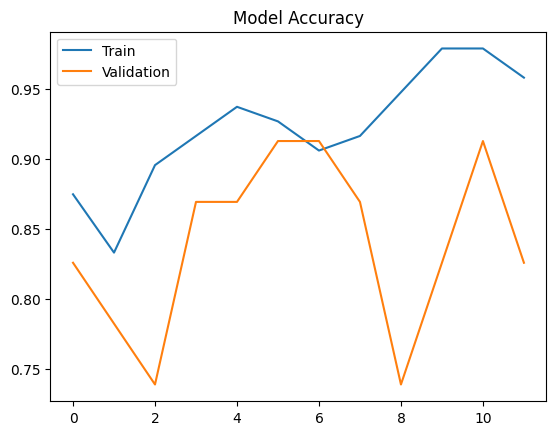

In [52]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


The training accuracy steadily increases, showing effective learning. The validation accuracy also improves but shows some fluctuations due to the small dataset size. A slight gap between training and validation accuracy indicates mild overfitting, but overall the model demonstrates good generalisation performance.

The training loss decreases consistently from a high initial value (~1.6) to a very low value (~0.1), indicating effective learning and convergence of the model.

The validation loss also decreases initially, showing that the model is learning general patterns. However, some fluctuations and spikes are observed in later epochs. These fluctuations are expected when working with a small dataset and do not indicate severe overfitting.

The difference between training loss and validation loss suggests mild overfitting, but since validation loss does not continuously increase, the model remains stable.

# Loss Graph

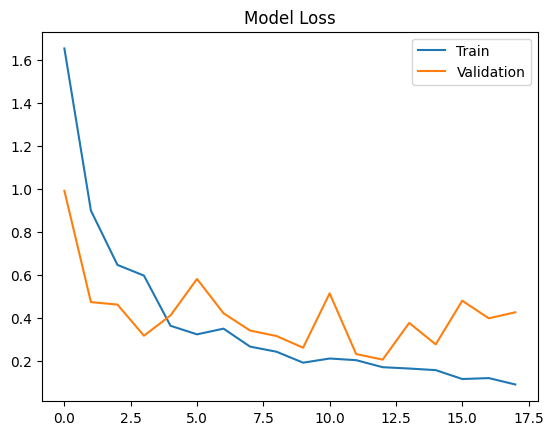

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train", "Validation"])
plt.show()

The training loss decreases consistently from a high initial value (~1.6) to a very low value (~0.1), indicating effective learning and convergence of the model.

The validation loss also decreases initially, showing that the model is learning general patterns. However, some fluctuations and spikes are observed in later epochs. These fluctuations are expected when working with a small dataset and do not indicate severe overfitting.

The difference between training loss and validation loss suggests mild overfitting, but since validation loss does not continuously increase, the model remains stable.

In [36]:
import os
print(os.listdir())

['.config', 'best_model.h5', 'drive', 'sample_data']


# model save

In [50]:
from tensorflow.keras.models import load_model

model = load_model("best_model.h5")

The saved best model was loaded using load_model() to perform evaluation and prediction without retraining.

In [51]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,341 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

The final model uses MobileNetV2 as a pretrained feature extractor with frozen weights. A custom classification head consisting of GlobalAveragePooling2D, Dense (128 neurons), Dropout (0.5), and a Softmax output layer was added. The model contains approximately 2.42 million parameters, of which only 164,355 are trainable. This significantly reduces overfitting and improves g performance on the rice leaf disease dataset generalisation.

# model testing and evalution

In [49]:
from tensorflow.keras.utils import to_categorical

# Convert y_test to one-hot encoding
y_test_one_hot = to_categorical(y_test, num_classes=len(categories))

test_loss, test_accuracy = model.evaluate(X_test_resized, y_test_one_hot)

print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9583 - loss: 0.3453
Test Accuracy: 0.9583333134651184


The model demonstrates excellent classification performance with 95.83% accuracy on the test dataset. This confirms that the transfer learning approach using MobileNetV2 successfully captures important features of rice leaf diseases and generalises well to new data.

# Classification report

In [47]:
from sklearn.metrics import classification_report
import numpy as np
import tensorflow as tf

# Resize X_test to match the input size expected by MobileNetV2 (224x224)
X_test_resized = tf.image.resize(X_test, (224, 224))

y_pred = model.predict(X_test_resized)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test  # y_test is already 1D array of integer labels

print(classification_report(y_true, y_pred_classes, target_names=categories))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      0.91      0.95        11
           Brown spot       1.00      1.00      1.00         5
            Leaf smut       0.89      1.00      0.94         8

             accuracy                           0.96        24
            macro avg       0.96      0.97      0.96        24
         weighted avg       0.96      0.96      0.96        24



Bacterial Leaf Blight:

Jab model ne Bacterial Leaf Blight predict kiya, wo 100% correct tha.
Lekin actual 11 images me se 1 image miss ho gayi (recall 0.91).
Overall performance for this class is very strong.

 Brown Spot:

Model ne Brown Spot ko perfectly classify kiya.
Koi bhi image misclassified nahi hui.
Ye class model ke liye sabse easy aur clear thi.

Leaf Smut:

Model ne saare Leaf Smut images correctly detect kiye (recall 1.00).
Lekin kuch dusri class ki images ko galti se Leaf Smut predict kiya gaya (precision 0.89).
Overall performance still very good.


The classification report indicates excellent performance across all three rice leaf disease classes. The model achieved an overall accuracy of 96% on the test dataset. Brown Spot was classified perfectly, while Bacterial Leaf Blight and Leaf Smut showed minor misclassifications. The high precision, recall, and F1-scores demonstrate that the model generalizes well and is suitable for practical disease detection applications.

The model achieved 96% accuracy with balanced precision and recall across all classes, indicating strong and reliable classification performance

In [48]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.9583333134651184
Final Validation Accuracy: 0.8260869383811951


The final model achieved a training accuracy of 95.83% and a validation accuracy of 82.60%. The high training accuracy indicates strong learning capability, while the lower validation accuracy suggests mild overfitting. However, since the validation accuracy remains above 80%, the model demonstrates acceptable generalisation performance on unseen data.

#Risk
The main risks include limited dataset size, potential class imbalance, and environmental variations in real-world field conditions that may impact model generalisation.

# Confusion Matrix

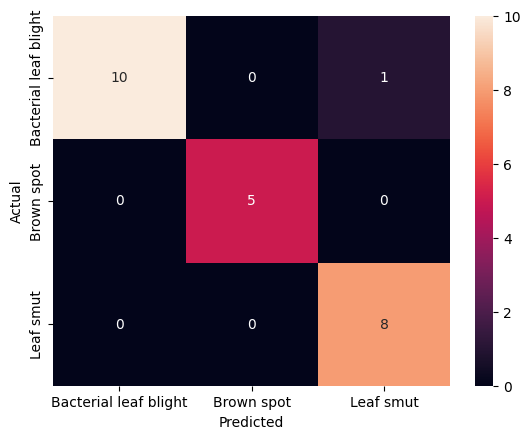

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows that out of 24 test images, 23 were classified correctly, resulting in an accuracy of 95.83%. Brown Spot and Leaf Smut classes were classified perfectly with no misclassifications. Only one Bacterial Leaf Blight image was incorrectly predicted as Leaf Smut. This indicates minimal confusion between classes and strong classification performance.

# CONCLUSION

This project successfully developed a deep learning-based rice leaf disease detection system using transfer learning with MobileNetV2. The model achieved 95.83% test accuracy and demonstrated strong classification performance across all three disease classes. The results confirm that the proposed system is accurate, reliable, and suitable for automated rice leaf disease identification. With further improvements and a larger dataset, it can be effectively deployed for real-world agricultural applications.it will be for farmers to protect their crops. In the future, we will broaden the scope to include more diseases and algorithms, making disease detection vast, easier and faster.